# Property feature correlation heatmaps

Pearson correlation of the numeric columns that are sufficiently populated (at least 30% non-missing) in each dataset. Identifier and coordinate columns are excluded.

In [1]:
from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

DATA_DIR = Path.cwd()
DATASETS = {
    "For sale": DATA_DIR / "forsale.csv",
    "To rent": DATA_DIR / "torent.csv",
}

# Keep a numeric column only if at least this fraction of rows have a value.
MIN_NON_NULL_FRACTION = 0.3

# Numeric but not meaningful to correlate (identifiers / coordinates).
EXCLUDE = {"latitude", "longitude", "postal_code"}


def numeric_correlation(csv_path):
    """Load a dataset and return the correlation matrix of its well-populated
    numeric columns."""
    df = pd.read_csv(csv_path, low_memory=False)

    # Coerce everything we can to numeric; non-numeric columns become all-NaN.
    numeric = df.apply(pd.to_numeric, errors="coerce")

    # Drop columns that are too sparse or explicitly excluded.
    threshold = int(len(numeric) * MIN_NON_NULL_FRACTION)
    kept = numeric.dropna(axis=1, thresh=threshold)
    kept = kept.drop(columns=[c for c in EXCLUDE if c in kept.columns])

    # Drop constant columns (correlation is undefined for those).
    kept = kept.loc[:, kept.nunique(dropna=True) > 1]

    return kept.corr(numeric_only=True)


## For sale

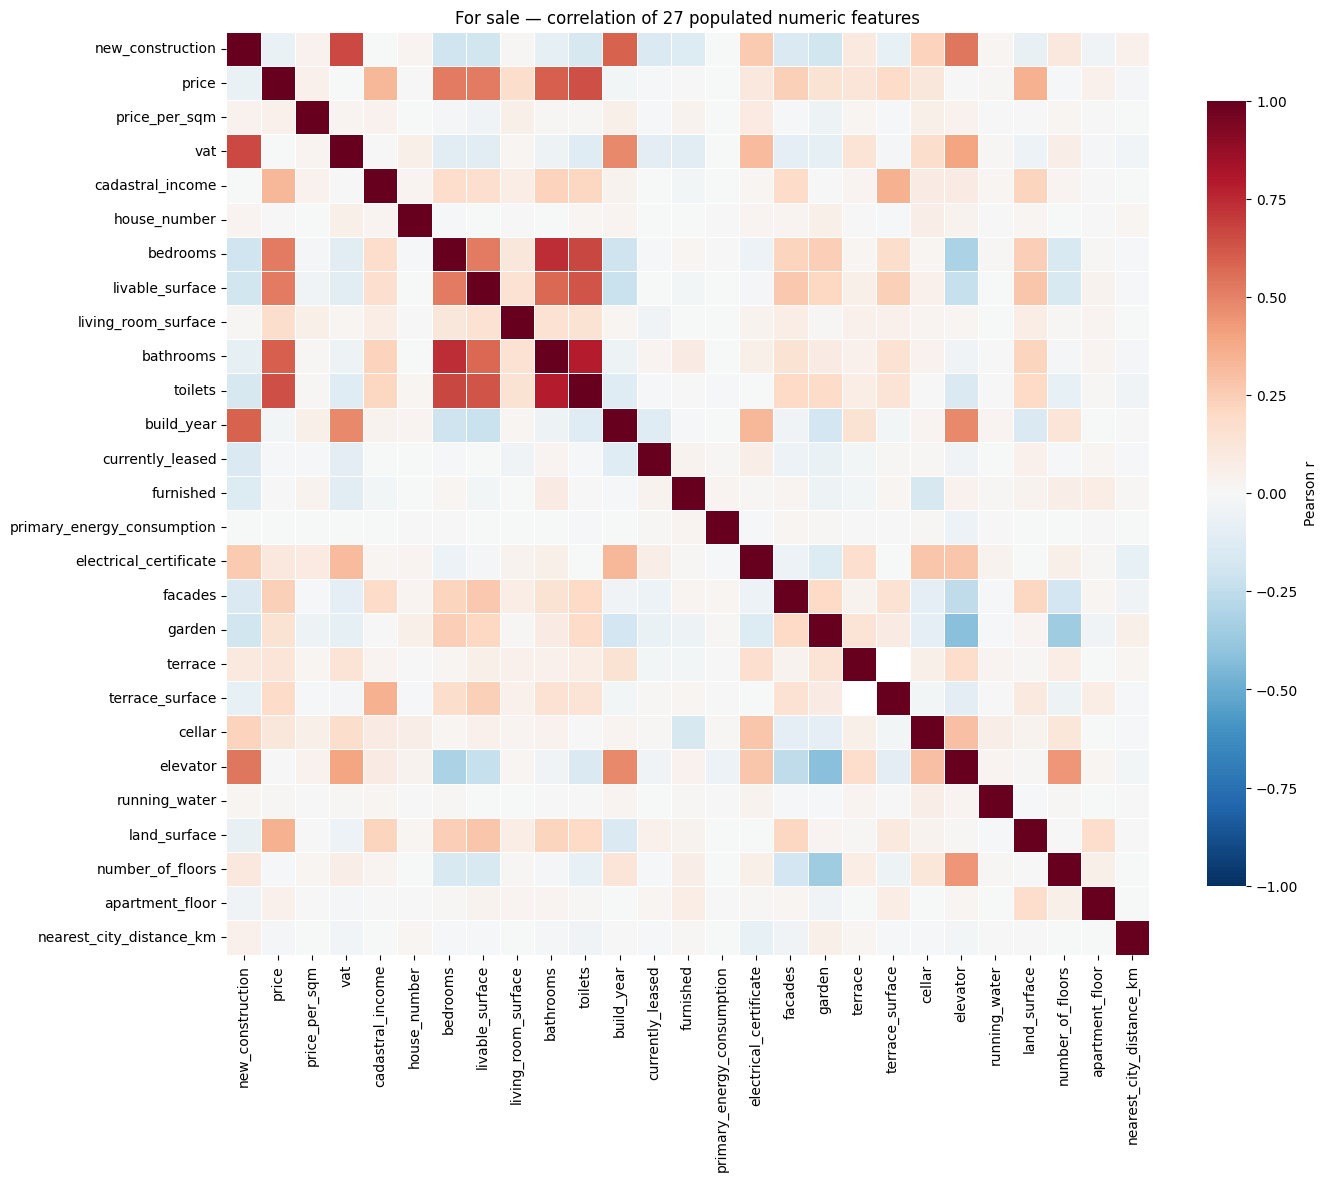

In [2]:
corr = numeric_correlation(DATASETS["For sale"])

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    corr,
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8, "label": "Pearson r"},
    ax=ax,
)
ax.set_title(
    "For sale — correlation of %d populated numeric features" % len(corr.columns)
)
plt.tight_layout()
plt.show()


## To rent

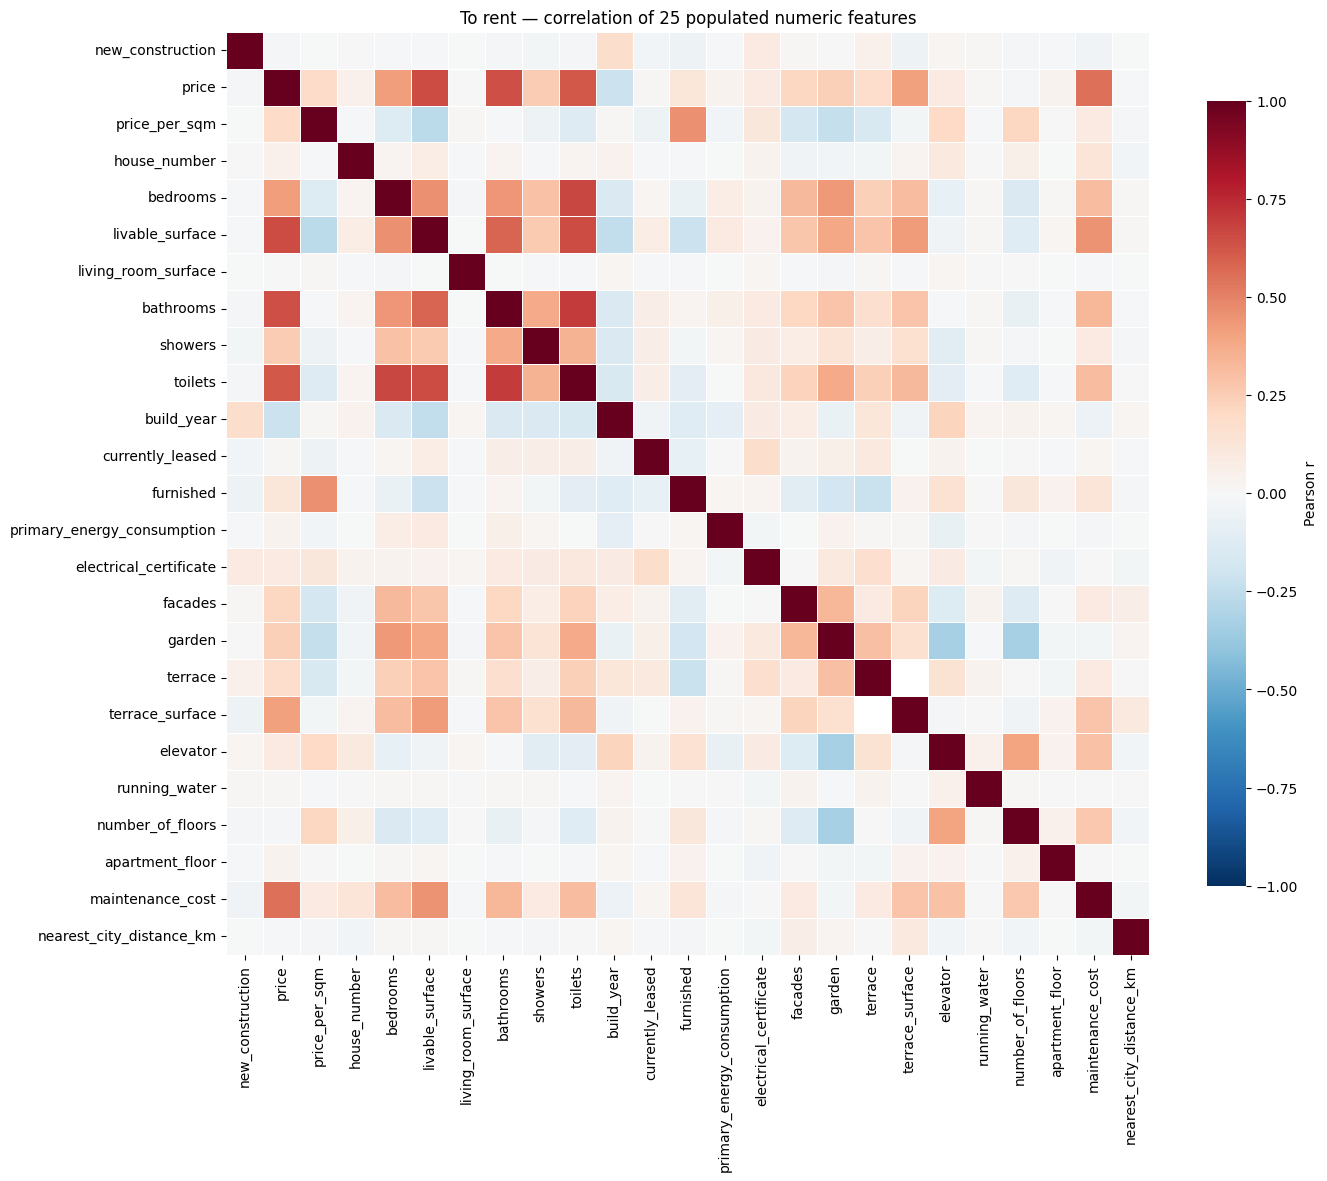

In [3]:
corr = numeric_correlation(DATASETS["To rent"])

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    corr,
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8, "label": "Pearson r"},
    ax=ax,
)
ax.set_title(
    "To rent — correlation of %d populated numeric features" % len(corr.columns)
)
plt.tight_layout()
plt.show()
